# Task 3 — AdaBoost for Imbalanced Data

This notebook completes Task 3 from the homework. The executable implementation is in `task3_adaboost.py`, and this notebook adds the required explanations, formulas, experiment tables, and plots.


## Imports and Shared Code

The AdaBoost.M1 boosting loop is implemented manually in `AdaBoostM1`. The only scikit-learn classifier used is `DecisionTreeClassifier(max_depth=1)`, which the homework explicitly permits as the weak learner. SMOTE is implemented from scratch with NumPy distance calculations.


In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd() / "code"))

from task1_hddt import SEEDS, compute_metrics, preprocess_train_test, resolve_dataset_path
from task3_adaboost import (
    BOOSTING_T_VALUES,
    AdaBoostM1,
    build_full_comparison,
    format_mean_std_table,
    plot_boosting_rounds,
    run_adaboost_experiments,
    run_boosting_round_experiment,
    run_smote_comparison,
    smote_oversample,
)


## Load the Dataset

The dataset has a severe class imbalance: `+1` is the minority severe class and `-1` is the majority non-severe class. This imbalance is why plain AdaBoost may focus mostly on classifying the majority class correctly.


In [2]:
data_path = resolve_dataset_path("../Covid.csv")
df = pd.read_csv(data_path)

print(f"Dataset path: {data_path}")
print(f"Dataset shape: {df.shape}")
print("Class distribution:")
print(df["Label"].value_counts().sort_index())


Dataset path: ../Covid.csv
Dataset shape: (1585, 41)
Class distribution:
Label
-1    1485
 1     100
Name: count, dtype: int64


## Preprocessing Before AdaBoost and SMOTE

The same leakage-safe preprocessing from Task 1 is used:

1. Stratified 70/30 train/test split.
2. Train-fitted imputation.
3. Kendall feature selection on the training split only.
4. Standard scaling only if retained continuous features exist.

SMOTE is applied only after this split and only to the training data.


In [3]:
X_train, X_test, y_train, y_test, preprocessing_info = preprocess_train_test(df, seed=42)

print(f"Train shape after preprocessing: {X_train.shape}")
print(f"Test shape after preprocessing: {X_test.shape}")
print(f"Selected features: {len(preprocessing_info['selected_features'])}")
print(f"Continuous scaled features: {preprocessing_info['continuous_scaled']}")
preprocessing_info["removed_features"]


Train shape after preprocessing: (1109, 39)
Test shape after preprocessing: (476, 39)
Selected features: 39
Continuous scaled features: []


,removed_feature,kept_feature,abs_kendall_between_features,removed_abs_corr_with_label,kept_abs_corr_with_label
0,vomiting,nausea,0.766494,0.075083,0.075083


## AdaBoost.M1 Formula

AdaBoost starts with uniform sample weights:

$$
w_i = \frac{1}{N}
$$

At round `t`, a weighted decision stump `h_t` is trained. Its weighted error is:

$$
\epsilon_t = \sum_i w_i \cdot \mathbf{1}[h_t(x_i) \ne y_i]
$$

The learner weight is:

$$
\alpha_t = \frac{1}{2}\log\left(\frac{1 - \epsilon_t}{\epsilon_t}\right)
$$

Then sample weights are updated by:

$$
w_i \leftarrow w_i \exp(-\alpha_t y_i h_t(x_i))
$$

and normalized. Misclassified samples receive larger weight in the next round.


In [4]:
plain_model = AdaBoostM1(T=50, learning_rate=1.0, random_state=42)
plain_model.fit(X_train, y_train)

plain_pred = plain_model.predict(X_test)
plain_score = plain_model.predict_proba(X_test)

print(f"Number of weak learners used: {len(plain_model.estimators_)}")
pd.DataFrame([compute_metrics(y_test, plain_pred, plain_score)]).round(4)


Number of weak learners used: 50


,Accuracy,Precision (+1),Recall (+1),F1-score (+1),AUC-ROC,G-mean
0,0.9328,0.0,0.0,0.0,0.6585,0.0


## SMOTE Oversampling Formula

For each synthetic minority sample, SMOTE selects a minority point `x_i`, one of its `k` nearest minority neighbors `x_neighbor`, and a random interpolation value `lambda`:

$$
x_{new} = x_i + \lambda (x_{neighbor} - x_i), \quad \lambda \sim Uniform(0,1)
$$

The important leakage rule is that SMOTE is applied only to the training split. Applying it before the split would create synthetic examples related to test samples and inflate the reported performance.


In [5]:
X_train_smote, y_train_smote = smote_oversample(X_train, y_train, k=5, random_state=42)

print("Before SMOTE:")
print(pd.Series(y_train).value_counts().sort_index())
print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())
print(f"SMOTE train shape: {X_train_smote.shape}")


Before SMOTE:
-1    1039
 1      70
Name: count, dtype: int64

After SMOTE:
-1    1039
 1    1039
Name: count, dtype: int64
SMOTE train shape: (2078, 39)


## Experiment A — AdaBoost vs. AdaBoost + SMOTE

The homework asks for a 10-run stratified evaluation with seeds `0` through `9`, comparing:

- AdaBoost with `T=50` on the original imbalanced training data.
- AdaBoost with `T=50` after SMOTE oversampling of the training data.

The table reports mean ± standard deviation across the 10 runs.


In [6]:
smote_comparison = run_smote_comparison(df, T=50, seeds=SEEDS)
smote_comparison_table = format_mean_std_table(smote_comparison, "method")
smote_comparison_table


,method,Accuracy,Precision (+1),Recall (+1),F1-score (+1),AUC-ROC,G-mean
0,AdaBoost (no SMOTE),0.9368 +/- 0.0007,0.0000 +/- 0.0000,0.0000 +/- 0.0000,0.0000 +/- 0.0000,0.6113 +/- 0.0267,0.0000 +/- 0.0000
1,AdaBoost + SMOTE,0.7971 +/- 0.0411,0.0888 +/- 0.0268,0.2400 +/- 0.1205,0.1263 +/- 0.0400,0.5811 +/- 0.0471,0.4343 +/- 0.0938


## Experiment B — Number of Boosting Rounds

With SMOTE applied, the homework asks us to vary:

`T in {10, 25, 50, 100}`

For each `T`, we record train error, test error, and minority-class F1. A decreasing train error with flat or worsening test F1 can indicate overfitting.


In [7]:
round_results = run_boosting_round_experiment(df, T_values=BOOSTING_T_VALUES, seeds=SEEDS)
round_summary = format_mean_std_table(
    round_results,
    "T",
    metric_cols=["train_error", "test_error", "F1-score (+1)"],
)
round_summary


,T,train_error,test_error,F1-score (+1)
0,10,0.2813 +/- 0.0291,0.3658 +/- 0.0548,0.1323 +/- 0.0206
1,25,0.2157 +/- 0.0280,0.2603 +/- 0.0547,0.1408 +/- 0.0320
2,50,0.1550 +/- 0.0240,0.2029 +/- 0.0411,0.1263 +/- 0.0400
3,100,0.1085 +/- 0.0163,0.1542 +/- 0.0275,0.1381 +/- 0.0341


## Plot Train Error, Test Error, and F1 vs. `T`

This plot helps identify whether adding more boosting rounds continues to help. The useful region is where test error decreases or F1 improves without a large overfitting gap.


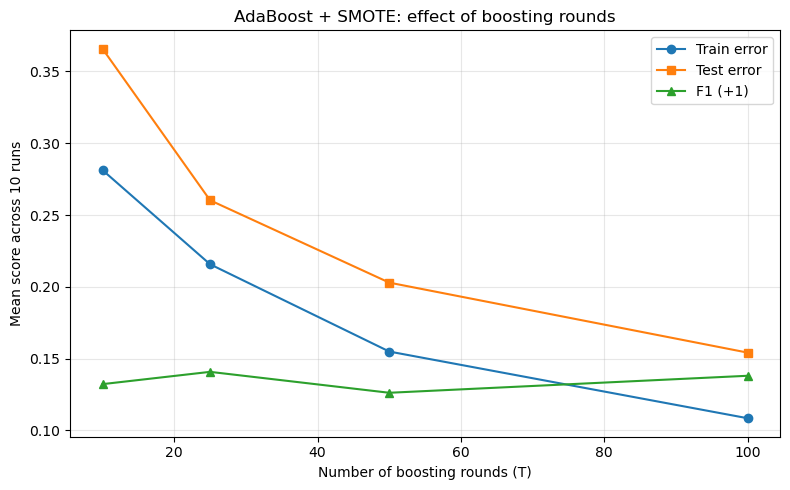

In [8]:
ax = plot_boosting_rounds(round_results)
plt.show()


## Best Number of Boosting Rounds with SMOTE

This ranking sorts the tested `T` values by mean minority-class F1, then by G-mean. Since the severe class is the minority class, F1 and G-mean are more informative than accuracy alone.


In [9]:
round_ranking = (
    round_results
    .groupby("T")[["F1-score (+1)", "G-mean", "Recall (+1)", "Precision (+1)", "Accuracy", "AUC-ROC", "train_error", "test_error"]]
    .mean()
    .sort_values(["F1-score (+1)", "G-mean"], ascending=False)
)
round_ranking.round(4)


,F1-score (+1),G-mean,Recall (+1),Precision (+1),Accuracy,AUC-ROC,train_error,test_error
T,,,,,,,,
25,0.1408,0.5025,0.3433,0.0900,0.7397,0.5837,0.2157,0.2603
100,0.1381,0.4122,0.1967,0.1099,0.8458,0.6070,0.1085,0.1542
10,0.1323,0.5299,0.4433,0.0781,0.6342,0.5506,0.2813,0.3658
50,0.1263,0.4343,0.2400,0.0888,0.7971,0.5811,0.1550,0.2029


## Full Comparison Across Implemented Methods

The homework asks for a final summary comparing the best configuration of each method. This cell computes that table using the Task 1, Task 2, and Task 3 implementations already created. The best config is selected by mean F1 for the minority class, with G-mean as the secondary criterion.


In [ ]:
full_comparison = build_full_comparison(df, seeds=SEEDS)
full_comparison.round(4)

,Method,Best Config,F1 (+1),G-mean,AUC-ROC
2,Bagging + DT (Task 2),"T=51, max_depth=3",0.1474,0.5501,0.6398
1,AdaBoost + SMOTE (Task 3),T=25,0.1408,0.5025,0.5837
3,Bagging + HDDT (Task 2),"T=11, max_depth=3",0.1371,0.4615,0.6371
4,HDDT (Task 1),max_depth=None,0.1023,0.2710,0.5846
0,AdaBoost (Task 3),T=10,0.0000,0.0000,0.5483
